## <font color='cornflowerblue'> Dependencies

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import vartools as vt
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

np.random.seed(42)
plt.rcParams['figure.facecolor'] = 'lightgray'

## <font color='cornflowerblue'> Optimal Weights

In [2]:
tickers = ['NVDA','AMZN','AVGO','PG','V','RL','GLD']

benchmark = 'SPY'
start_date = (datetime.today() - timedelta(days=365*2)).strftime('%Y-%m-%d')
end_date = datetime.today().strftime('%Y-%m-%d')

data = yf.download(tickers, start=start_date, end=end_date, progress=False, auto_adjust=True)['Close'][tickers]
benchmark_data = yf.download(benchmark, start=start_date, end=end_date, progress=False, auto_adjust=True)['Close']

# Adjust optimization window
months = 3
n_days = round(len(benchmark_data) / round(len(benchmark_data) / 252 / (months / 12)), 0) 

# Benchmark
benchmark_data = benchmark_data.iloc[-int(n_days):, :]
rt_benchmark = benchmark_data.pct_change().dropna()

# Stocks
data = data.iloc[-int(n_days):, :]
rt = data.pct_change().dropna()

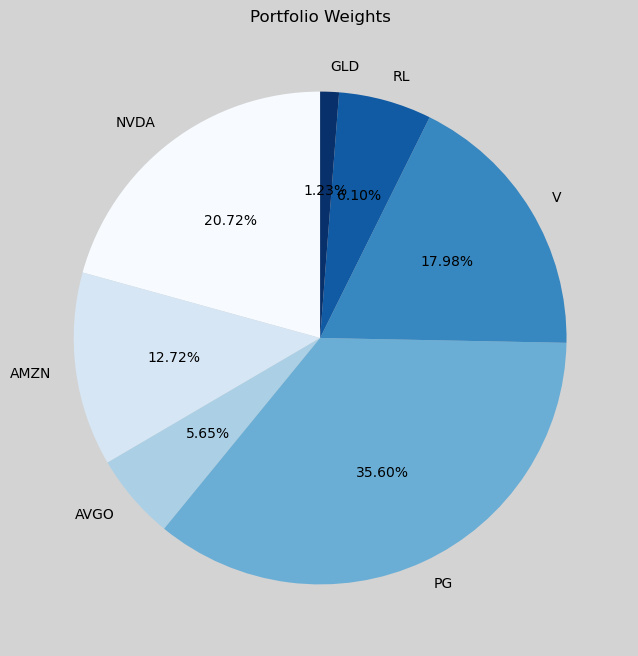

In [3]:
optimizer = vt.OptimizePortfolioWeights(rt, risk_free=0.0375)
weights = optimizer.opt_min_semivar(rt_benchmark)
vt.plot_weights(tickers, weights)

## <font color='cornflowerblue'> Rebalancing

In [4]:
pd.set_option('display.float_format', '{:.4f}'.format)

start_date = (datetime.today() - timedelta(days=3)).strftime('%Y-%m-%d')
end_date = (datetime.today() + timedelta(days=1)).strftime('%Y-%m-%d')

price = yf.download(tickers, start=start_date, end=end_date, progress=False, auto_adjust=True)['Close'][tickers]
#w_original = np.ones(len(tickers)) / len(tickers)
w_original = np.zeros(len(tickers))

rebalance_df = vt.rebalance_stocks(w_original=w_original,
                target_weights=weights,
                data=price,
                stocks=tickers,
                portfolio_value=1000)
rebalance_df

Ticker,NVDA,AMZN,AVGO,PG,V,RL,GLD
Original Weights,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
Target Weights,0.2072,0.1272,0.0565,0.3560,0.1798,0.0610,0.0123
Shares (Buy/Sell),1.0839,0.5316,0.1706,2.3457,0.5587,0.1726,0.0276


## <font color='cornflowerblue'> Predicting

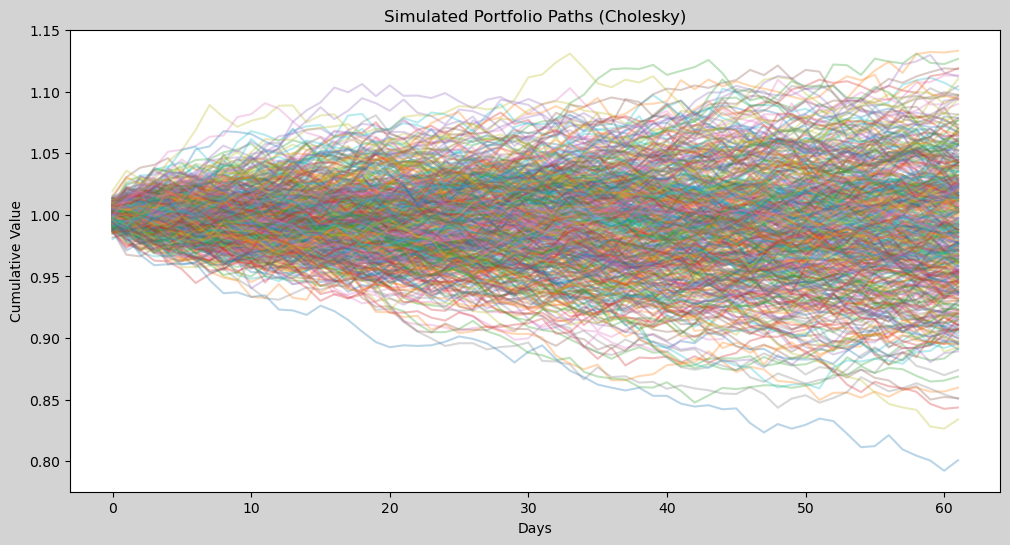

1st Quartile (25th Percentile): -4.5225%
Mean Cumulative Return: -0.7832%
Median Cumulative Return: -0.9488%
3rd Quartile (75th Percentile): 2.7688%

Probability of Positive Return in 62 days: 43.00%


In [5]:
simulated_portfolios = vt.simulate_portfolio(data, weights, int(n_days))

plt.figure(figsize=(12, 6))
plt.plot(simulated_portfolios[:, :500], alpha=0.3)
plt.title("Simulated Portfolio Paths (Cholesky)")
plt.xlabel("Days")
plt.ylabel("Cumulative Value")
plt.show()

final_cumulative_return = simulated_portfolios[-1, :] - 1

mean = np.mean(final_cumulative_return)
median = np.median(final_cumulative_return)
q1 = np.percentile(final_cumulative_return, 25)
q3 = np.percentile(final_cumulative_return, 75)
prob_win = np.mean(final_cumulative_return > 0)

print(f"1st Quartile (25th Percentile): {q1:.4%}")
print(f"Mean Cumulative Return: {mean:.4%}")
print(f"Median Cumulative Return: {median:.4%}")
print(f"3rd Quartile (75th Percentile): {q3:.4%}\n")
print(f"Probability of Positive Return in {int(n_days)} days: {prob_win:.2%}")